In [376]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

sys.path.append(os.path.abspath('../../'))

from neuro_fuzzy_toolbox import h_ANFIS, Hybrid_learning_algorithm, EarlyStopping, get_measures

In [377]:
import numpy as np

In [378]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

## Data

In [379]:
def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))

#Training
x0 = np.random.uniform(-3,3,1000)
x1 = np.random.uniform(-3,3,1000)

e = np.random.normal(0,0.7,1000) #noise
Y = z(x0,x1) + e

#Testing
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)

In [380]:
Y.mean(), Y.std()

(np.float64(0.39725287542383453), np.float64(2.0443348072701184))

In [381]:
Y_test.mean(), Y_test.std()

(np.float64(0.36182047228016107), np.float64(1.8933659547440587))

In [382]:
#Training
scaler = MinMaxScaler(feature_range=(-1, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)

#Testing
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.transform(vstack_test)

In [ ]:
train_loader = data.DataLoader(
    data.TensorDataset(
        torch.tensor(scaled_train, dtype=torch.float32), 
        torch.tensor(Y, dtype=torch.float32)
        ), 
    batch_size = 32, 
    shuffle = True)

In [384]:
x_train = train_loader.dataset.tensors[0]
y_train = train_loader.dataset.tensors[1]

x_test = torch.tensor(scaled_test, dtype=torch.float32)
y_test = torch.tensor(Y_test, dtype=torch.float32)

## Model & Training

In [ ]:
model = h_ANFIS(
    input_size = 2,
    num_mfs = 6,
    outputs = 1,
    rule_reduced = False,
    dtype = x_train.dtype
)

In [386]:
model.init_premises(x_train)

In [387]:
model.show_premises_structure()

      a (x0)  b (x0)  c (x0)  a (x1)  b (x1)  c (x1)
MF 0     0.2     4.0    -1.0     0.2     4.0    -1.0
MF 1     0.2     4.0    -0.6     0.2     4.0    -0.6
MF 2     0.2     4.0    -0.2     0.2     4.0    -0.2
MF 3     0.2     4.0     0.2     0.2     4.0     0.2
MF 4     0.2     4.0     0.6     0.2     4.0     0.6
MF 5     0.2     4.0     1.0     0.2     4.0     1.0


In [388]:
model.get_premises()

tensor([[[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]],

        [[ 0.2000,  4.0000, -1.0000],
         [ 0.2000,  4.0000, -0.6000],
         [ 0.2000,  4.0000, -0.2000],
         [ 0.2000,  4.0000,  0.2000],
         [ 0.2000,  4.0000,  0.6000],
         [ 0.2000,  4.0000,  1.0000]]])

In [389]:
loss_fn = nn.functional.mse_loss
optimizer = torch.optim.AdamW
params = {'lr': 0.0001, 'weight_decay': 0.001}
early_stopping = EarlyStopping(patience=30)

trainer = Hybrid_learning_algorithm(
    epochs=500,
    loss_function=loss_fn,
    optimizer=optimizer,
    optimizer_params=params,
    validation=0.3,
    early_stopping=early_stopping
)

In [390]:
trainer(model, train_loader, verbose=True)

Epoch:   1/500 - loss: 0.480801 - validation loss: 0.721475
Epoch:   2/500 - loss: 0.477840 - validation loss: 0.718508
Epoch:   3/500 - loss: 0.475277 - validation loss: 0.716161
Epoch:   4/500 - loss: 0.472659 - validation loss: 0.713498
Epoch:   5/500 - loss: 0.470017 - validation loss: 0.711177
Epoch:   6/500 - loss: 0.467647 - validation loss: 0.708426
Epoch:   7/500 - loss: 0.464859 - validation loss: 0.706709
Epoch:   8/500 - loss: 0.462323 - validation loss: 0.703486
Epoch:   9/500 - loss: 0.460128 - validation loss: 0.701562
Epoch:  10/500 - loss: 0.457874 - validation loss: 0.698973
Epoch:  11/500 - loss: 0.455350 - validation loss: 0.696706
Epoch:  12/500 - loss: 0.452771 - validation loss: 0.694189
Epoch:  13/500 - loss: 0.450527 - validation loss: 0.692190
Epoch:  14/500 - loss: 0.448317 - validation loss: 0.689814
Epoch:  15/500 - loss: 0.446008 - validation loss: 0.687502
Epoch:  16/500 - loss: 0.443802 - validation loss: 0.684893
Epoch:  17/500 - loss: 0.441731 - valida

In [391]:
model.show_premises_structure()

        a (x0)    b (x0)    c (x0)    a (x1)    b (x1)    c (x1)
MF 0  0.231212  4.029260 -0.959170  0.238555  3.932235 -0.966970
MF 1  0.143776  4.009979 -0.572151  0.260912  3.875885 -0.565425
MF 2  0.222829  3.959864 -0.178846  0.226810  3.964038 -0.186561
MF 3  0.241203  3.976392  0.187688  0.205695  3.933767  0.219596
MF 4  0.213502  3.956518  0.520101  0.230605  3.978302  0.550588
MF 5  0.267259  3.975360  0.929046  0.214143  3.945530  0.991404


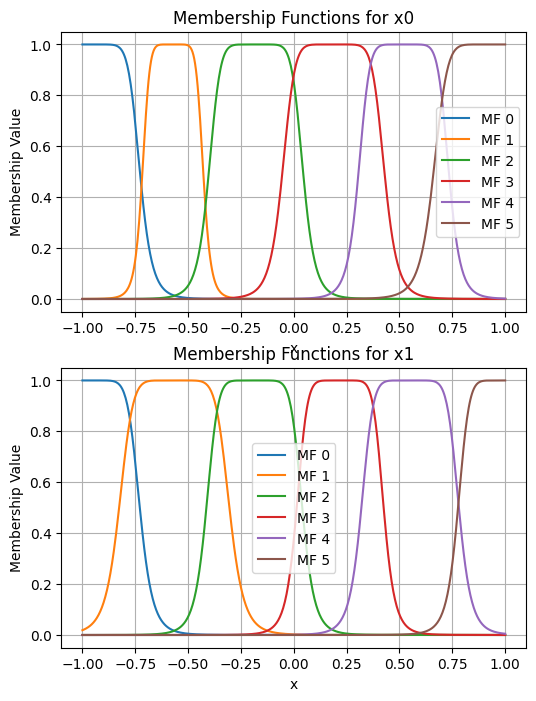

In [392]:
model.plot_premises(group_by_dim=True)

In [393]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.231212,4.029260,-0.959170,0.238555,3.932235,-0.966970
MF 1,0.143776,4.009979,-0.572151,0.260912,3.875885,-0.565425
MF 2,0.222829,3.959864,-0.178846,0.226810,3.964038,-0.186561
MF 3,0.241203,3.976392,0.187688,0.205695,3.933767,0.219596
MF 4,0.213502,3.956518,0.520101,0.230605,3.978302,0.550588
MF 5,0.267259,3.975360,0.929046,0.214143,3.945530,0.991404


In [394]:
test_measures = get_measures(model, x_test, y_test)

for measure in test_measures:
    print(measure + ':', test_measures[measure])

MSE: 0.12230610102415085
RMSE: 0.34972289204597473
MAE: 0.2811751365661621
R2: 0.9658823609352112
MAPE: 153.28375244140625


In [395]:
train_measures = get_measures(model, x_train, y_train)

for measure in train_measures:
    print(measure + ':', train_measures[measure])

MSE: 0.44998419284820557
RMSE: 0.6708086133003235
MAE: 0.5251083970069885
R2: 0.8923303484916687
MAPE: 1.5481904745101929


In [396]:
model.premises_structure

,a (x0),b (x0),c (x0),a (x1),b (x1),c (x1)
MF 0,0.231212,4.029260,-0.959170,0.238555,3.932235,-0.966970
MF 1,0.143776,4.009979,-0.572151,0.260912,3.875885,-0.565425
MF 2,0.222829,3.959864,-0.178846,0.226810,3.964038,-0.186561
MF 3,0.241203,3.976392,0.187688,0.205695,3.933767,0.219596
MF 4,0.213502,3.956518,0.520101,0.230605,3.978302,0.550588
MF 5,0.267259,3.975360,0.929046,0.214143,3.945530,0.991404


In [397]:
model.consequents_structure[0]

,c0 (x0),c1 (x1),c2
rule 1,1.586784,7.930147,8.492300
rule 2,2.395232,1.577658,2.771015
rule 3,-4.172960,3.640048,-2.917823
rule 4,-2.400545,4.584811,-3.567370
rule 5,1.813587,0.860559,1.286334
rule 6,5.910148,4.886830,0.814773
rule 7,-7.791309,11.242958,6.347534
rule 8,4.084524,8.343546,7.144922
rule 9,-4.222138,-5.858312,-5.054120
rule 10,1.203475,-3.693611,-0.027241
